# House Price Prediction (AP + Telangana)
Same workflow as the original `model.ipynb`, with only the mistakes fixed. Each fix is explained in the markdown cell above the code.

**Workflow:** load → check data → transform skewed columns → EDA → features → split → preprocess → Linear Regression → evaluate

## 1. Imports
`seaborn` is now imported here at the top instead of halfway down the notebook.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load data and check it
**Mistake:** only `df.head()` was run.

**Fix:** check shape, dtypes, missing values and duplicates *before* modelling. Duplicate rows can end up in both train and test, which makes the score look better than it really is.

In [55]:
df = pd.read_csv(r"ap_ts_dataset.csv")

print("shape:", df.shape)
df.info()
print("\nmissing values:\n", df.isna().sum())
print("\nduplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
df.head()

shape: (6510, 12)
<class 'pandas.DataFrame'>
RangeIndex: 6510 entries, 0 to 6509
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   state          6510 non-null   str  
 1   district       6510 non-null   str  
 2   city           6510 non-null   str  
 3   property_type  6510 non-null   str  
 4   beds           6510 non-null   int64
 5   baths          6510 non-null   int64
 6   size_sqft      6510 non-null   int64
 7   furnishing     6510 non-null   str  
 8   facing         6510 non-null   str  
 9   age_years      6510 non-null   int64
 10  price_inr      6510 non-null   int64
 11  locality_key   6510 non-null   str  
dtypes: int64(5), str(7)
memory usage: 610.4 KB

missing values:
 state            0
district         0
city             0
property_type    0
beds             0
baths            0
size_sqft        0
furnishing       0
facing           0
age_years        0
price_inr        0
locality_key     0
dtyp

,state,district,city,property_type,beds,baths,size_sqft,furnishing,facing,age_years,price_inr,locality_key
0,Telangana,Jangaon,Jangaon,Independent House,5,4,2590,Unfurnished,North,1,10125000,Jangaon | Jangaon Town
1,Telangana,Siddipet,Siddipet,Apartment,2,2,988,Unfurnished,East,0,2350000,Siddipet | Doultabad
2,Telangana,Sangareddy,Hyderabad,Apartment,2,2,1012,Unfurnished,North,0,7075000,Sangareddy | Ameenpur
3,Telangana,Kumuram Bheem Asifabad,Asifabad,Residential Plot,0,0,2403,Not Applicable,East,0,1075000,Kumuram Bheem Asifabad | Rebbena
4,Telangana,Rangareddy,Hyderabad,Residential Plot,0,0,3600,Not Applicable,South,0,16825000,Rangareddy | Nadargul


## 3. Target distribution
Price is heavily right-skewed (most homes are cheap, a few are very expensive). That is why we model `log(price)` instead of raw price.

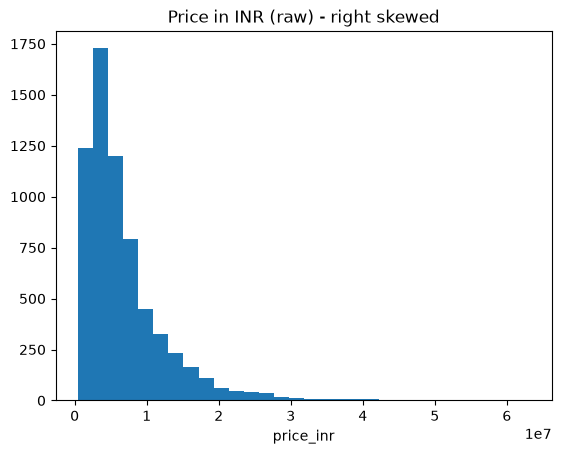

In [56]:
plt.hist(df["price_inr"], bins=30)
plt.title("Price in INR (raw) - right skewed")
plt.xlabel("price_inr")
plt.show()

## 4. Log transform
**Mistake:** three different-scale histograms were drawn on the same axis (`plt.hist(a), plt.hist(b), plt.hist(c)`), so the plot was meaningless.

**Fix:** one plot per variable.

**Note:** `age_years` has a big spike at 0 (plots and brand-new properties). A log transform cannot remove a spike, so an `is_new` flag is added so the model can treat age 0 separately.

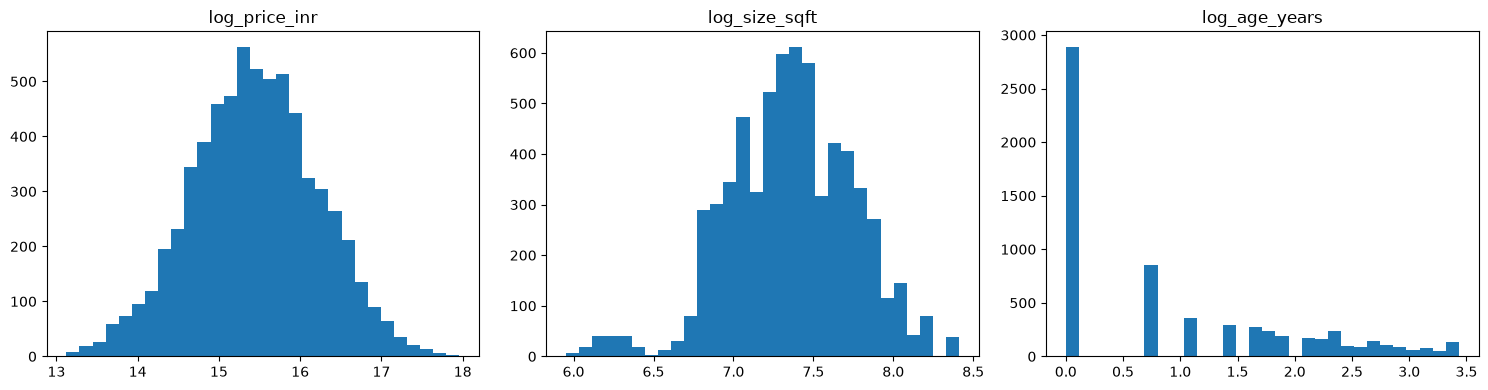

In [57]:
df["log_price_inr"] = np.log1p(df["price_inr"])
df["log_size_sqft"] = np.log1p(df["size_sqft"])
df["log_age_years"] = np.log1p(df["age_years"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["log_price_inr", "log_size_sqft", "log_age_years"]):
    ax.hist(df[col], bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. EDA plots and skewness
**Mistakes:**
- Plot titles said "Price in INR" / "Age of House" but the data plotted was the *log* version.
- Skewness was printed for the **raw** columns only, so it never showed whether the log transform helped.

**Fix:** correct titles, and print skew before and after.

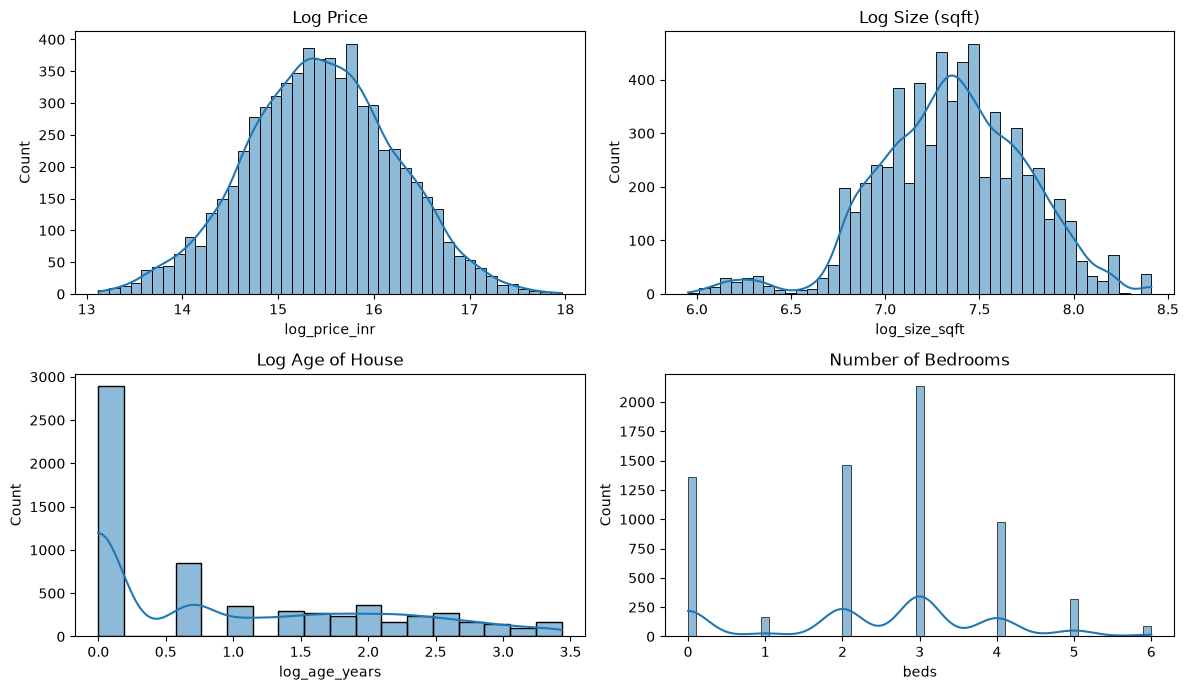

       before (raw)  after (log)
price      2.573263    -0.011689
size       1.007071    -0.280786
age        2.187723     0.672093


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

sns.histplot(df["log_price_inr"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Log Price")

sns.histplot(df["log_size_sqft"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Log Size (sqft)")

sns.histplot(df["log_age_years"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Log Age of House")

sns.histplot(df["beds"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Number of Bedrooms")

plt.tight_layout()
plt.show()

skew = pd.DataFrame({
    "before (raw)": df[["price_inr", "size_sqft", "age_years"]].skew().values,
    "after (log)": df[["log_price_inr", "log_size_sqft", "log_age_years"]].skew().values,
}, index=["price", "size", "age"])
print(skew)

## 6. Choose features
**Fix:** added `state` (the dataset contains both Andhra Pradesh and Telangana) and the `is_new` flag from step 4.

In [59]:
target_encoded = ["district", "locality_key"]
one_hot = ["state", "property_type", "furnishing", "facing"]

numerical_features = [
    "beds",
    "baths",
    "log_size_sqft",
    "log_age_years",
]
feature_columns = target_encoded + numerical_features + one_hot

## 7. Train / test split

In [60]:
from sklearn.model_selection import train_test_split

X = df[feature_columns]
y = df["log_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, y_train.shape

((5208, 10), (5208,))

In [61]:
X_train.columns.to_list()

['district',
 'locality_key',
 'beds',
 'baths',
 'log_size_sqft',
 'log_age_years',
 'state',
 'property_type',
 'furnishing',
 'facing']

## 8. Preprocessing
- Numbers: `StandardScaler`
- High-cardinality columns (`district`, `locality_key`): `TargetEncoder` - fitted **only on training data** because it lives inside the pipeline
- Low-cardinality columns: `OneHotEncoder`

**Fixes:** typo `categorial_encoding` → `categorical_encoding`; `remainder="passthrough"` → `"drop"` (every feature is already listed, so passthrough did nothing, and drop is safer if a column is ever added by mistake).

In [62]:
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical_encoding", StandardScaler(), numerical_features),
        ("target_encoding", TargetEncoder(smoothing=10), target_encoded),
        ("categorical_encoding", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot),
    ],
    remainder="drop",
)

## 9. Train the model
**Mistake:** `y_test = np.expm1(y_test)` overwrote the test target. Running the cell twice exponentiates it twice and gives garbage metrics, and it also made log-scale evaluation impossible.

**Fix:** keep `y_test` (log scale) untouched and store the rupee version in a new variable `y_test_inr`.

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_test_inr = np.expm1(y_test)      # new variable - y_test stays on log scale

# Actual vs Predicted Prices Graph 

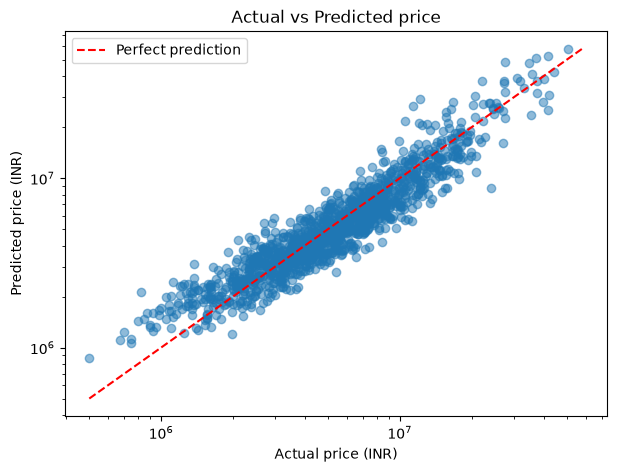

In [65]:
y_true = np.expm1(y_test)
pred = np.expm1(y_pred_log)

lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())

plt.figure(figsize=(7, 5))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([lo, hi], [lo, hi], "r--", label="Perfect prediction")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual price (INR)")
plt.ylabel("Predicted price (INR)")
plt.title("Actual vs Predicted price")
plt.legend()
plt.show()

In [66]:
bins = [0, 2e6, 5e6, 1e7, 2e7, np.inf]
labels = ["<20L", "20L-50L", "50L-1Cr", "1Cr-2Cr", ">2Cr"]

tmp = pd.DataFrame({"actual": y_true.values, "pred": y_pred})
tmp["bucket"] = pd.cut(tmp["actual"], bins=bins, labels=labels)
tmp["signed_pct_err"] = (tmp["pred"] - tmp["actual"]) / tmp["actual"] * 100
tmp["abs_pct_err"] = tmp["signed_pct_err"].abs()

summary = tmp.groupby("bucket", observed=True).agg(
    count=("actual", "size"),
    median_signed_pct_err=("signed_pct_err", "median"),
    median_abs_pct_err=("abs_pct_err", "median"),
).round(1)
print(summary)

tmp["property_type"] = X_test["property_type"].values
tmp["district"] = X_test["district"].values

check = tmp[tmp["bucket"].isin(["<20L", "50L-1Cr", "1Cr-2Cr"])]

print(check.groupby(["bucket", "property_type"], observed=True).agg(
    count=("actual", "size"),
    median_signed_pct_err=("signed_pct_err", "median"),
).round(1))

print("\nDistricts in the <20L bucket:")
print(tmp[tmp["bucket"] == "<20L"]["district"].value_counts().head(10))

         count  median_signed_pct_err  median_abs_pct_err
bucket                                                   
<20L       119                   37.7                38.1
20L-50L    505                    2.8                15.5
50L-1Cr    439                  -11.4                17.0
1Cr-2Cr    196                  -12.8                18.0
>2Cr        43                    2.7                20.2
                                   count  median_signed_pct_err
bucket  property_type                                          
<20L    Apartment                     41                   23.0
        Independent Builder Floor      3                   46.1
        Independent House             12                   42.4
        Residential Plot              63                   39.8
50L-1Cr Apartment                    176                  -11.6
        Independent Builder Floor     27                    3.2
        Independent House            165                  -15.0
        Residentia

## 10. Evaluation
**Mistakes:**
- MSE (6.07e12) is in *squared rupees* and can't be interpreted. Use **RMSE** (same unit as price).
- Only rupee-scale metrics were reported. R² on rupees is dominated by a few very expensive properties, so also report log-scale metrics (log RMSE ≈ relative % error) and the median % error.
- Train scores were not checked, so overfitting could not be seen.

**How to read it:** if train R² is much higher than test R², the model is overfitting. Median % error is the easiest number to explain: "typically off by X%".

In [67]:
def report(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "MAE (INR)": mean_absolute_error(y_true, y_pred),
        "RMSE (INR)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2 (INR)": r2_score(y_true, y_pred),
        "RMSE (log)": np.sqrt(mean_squared_error(y_true_log, y_pred_log)),
        "R2 (log)": r2_score(y_true_log, y_pred_log),
        "Median % error": np.median(np.abs(y_pred - y_true) / y_true) * 100,
    }

results = pd.DataFrame({
    "train": report(y_train, model.predict(X_train)),
    "test": report(y_test, y_pred_log),
}).T
results.round(3)

,MAE (INR),RMSE (INR),R2 (INR),RMSE (log),R2 (log),Median % error
train,1438901.274,2714090.644,0.794,0.255,0.893,17.431
test,1403086.183,2424537.253,0.832,0.263,0.874,17.553


## 11. Residual check
R² alone can hide systematic errors. If the residuals fan out or slope, the model is missing something (for example expensive houses being under-predicted). A straight linear model often does this because price depends on *combinations* of features (property type × size × locality).

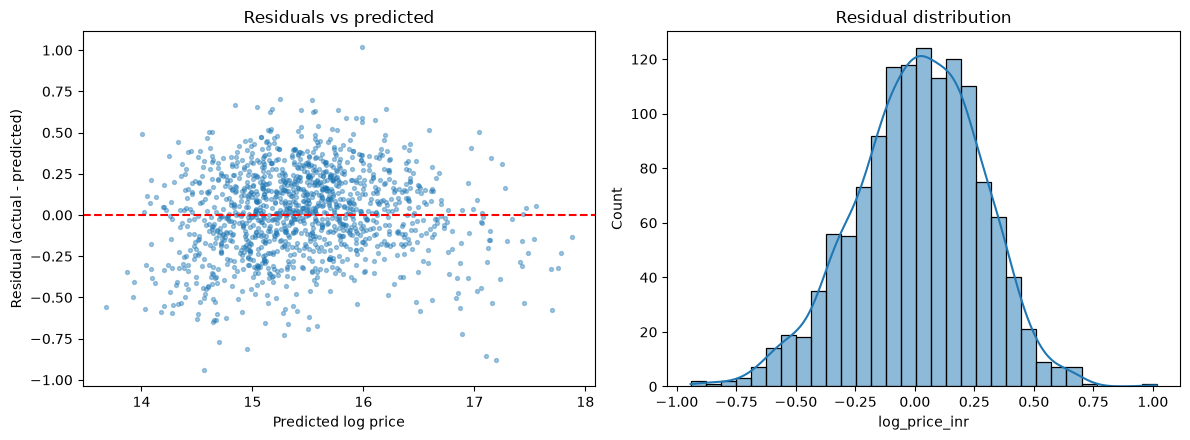

In [68]:
residuals = y_test - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred_log, residuals, s=8, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted log price")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")

plt.tight_layout()
plt.show()

## Summary of fixes
| Cell | Problem | Fix |
|---|---|---|
| Load | No data checks | shape / info / missing / duplicates, drop duplicates |
| Log transform | 3 histograms on one axis | one plot per variable |
| EDA | Wrong titles, skew shown for raw data only | correct titles, skew before vs after |
| Features | `state` dropped, age-0 spike ignored | added `state`, `is_new` |
| Preprocessor | typo, useless `passthrough` | renamed, `remainder="drop"` |
| Model | `y_test` overwritten | separate `y_test_inr` |
| Metrics | MSE unreadable, rupee scale only, no train score | RMSE, log-scale metrics, median % error, train vs test |
| Residuals | none | residual plots added |

# Saving a Model Using Joblib

The trained `model` is saved in `.pkl` format using the `joblib` library.

In [69]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

# Testing The Model 

In [70]:
import joblib
import numpy as np
import pandas as pd

# Loaded once when the server starts, not on every request
model = joblib.load("model.pkl")


def predict_price(state, district, locality_key, property_type,
                  beds, baths, size_sqft, furnishing, facing, age_years):
    row = pd.DataFrame([{
        "district": district,
        "locality_key": locality_key,      # format: "District | Locality"
        "beds": beds,
        "baths": baths,
        "log_size_sqft": np.log1p(size_sqft),
        "log_age_years": np.log1p(age_years),
        "state": state,
        "property_type": property_type,
        "furnishing": furnishing,
        "facing": facing,
    }])

    pred_log = model.predict(row)[0]
    return float(np.expm1(pred_log))     # back to rupees


if __name__ == "__main__":
    price = predict_price(
        state="Telangana",
        district="Rangareddy",
        locality_key="Rangareddy | Nadargul",
        property_type="Villa",
        beds=3,
        baths=2,
        size_sqft=1500,
        furnishing="furnished",
        facing="North",
        age_years=2,
    )
    print(f"Predicted price: ₹{price:,.0f}")

Predicted price: ₹11,817,128
